<center><h1>Vikraman_Madhulika_HW6</h1></center>

Name: Madhulika Vikraman
<br>
Github Username: madhulikavikraman
<br>
USC ID: 2083047114

## 1. Tree-Based Methods

Import packages

In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.impute import SimpleImputer
import math
from IPython.display import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

### (a) Download the APS Failure data

In [3]:
df_train = pd.read_csv("../data/aps_failure_training_set.csv", na_values="na", skiprows=20)
df_test = pd.read_csv("../data/aps_failure_test_set.csv", na_values="na", skiprows=20)
print(df_train.shape, df_test.shape)

(60000, 171) (16000, 171)


In [4]:
df_train

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,neg,153002,NaN,6.640000e+02,186.0,0.0,0.0,0.0,0.0,0.0,...,998500.0,566884.0,1290398.0,1218244.0,1019768.0,717762.0,898642.0,28588.0,0.0,0.0
59996,neg,2286,NaN,2.130707e+09,224.0,0.0,0.0,0.0,0.0,0.0,...,10578.0,6760.0,21126.0,68424.0,136.0,0.0,0.0,0.0,0.0,0.0
59997,neg,112,0.0,2.130706e+09,18.0,0.0,0.0,0.0,0.0,0.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
59998,neg,80292,NaN,2.130706e+09,494.0,0.0,0.0,0.0,0.0,0.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0


### (b) Data Preparation

#### (i) Research what types of techniques are usually used

There are several imputation methods to deal with missing data like :-

Mean - replace missing values with mean of non-missing values in the column

Median - replace missing values with median of non-missing values in the column

Mode - replace missing values with mode of non-missing values in the column

KNN - replace with weighted average of k nearest neighbours

Regression - missing values are replaced by values estimated by regression models

Constant - missing values are replaced by a constant like 0

Using mean imputation below

In [5]:
df_train_X = df_train.iloc[:, 1:]
df_train_y = df_train.iloc[:, 0]
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(df_train_X)
df_train_imputed = pd.DataFrame(imp.transform(df_train_X), columns=df_train_X.columns)

df_test_X = df_test.iloc[:, 1:]
df_test_y = df_test.iloc[:, 0]
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(df_test_X)
df_test_imputed = pd.DataFrame(imp.transform(df_test_X), columns=df_test_X.columns)

print(df_train_imputed.shape, df_test_imputed.shape)

df_imputed = pd.concat([df_train_imputed, df_test_imputed], axis=0)
print(df_imputed.shape)

(60000, 170) (16000, 170)
(76000, 170)


#### (ii) Calculate the coefficient of variation

In [6]:
coeff = df_imputed.describe().loc["std"] / df_imputed.describe().loc["mean"]
display(coeff)

aa_000      4.328608
ab_000      2.178397
ac_000      2.167648
ad_000    206.786809
ae_000     22.293998
             ...    
ee_007      4.885086
ee_008      3.335019
ee_009      5.753917
ef_000     47.925135
eg_000     45.648516
Length: 170, dtype: float64

#### (iii) Plot a correlation matrix

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
aa_000,1.000000,0.019908,-0.011646,-0.000574,0.025784,0.035977,0.011681,0.076379,0.195163,0.307445,...,0.414127,0.419914,0.409662,0.419784,0.425682,0.356969,0.259670,0.133764,0.006660,0.010344
ab_000,0.019908,1.000000,-0.010893,0.000026,0.024889,0.043279,0.000557,0.006667,0.023633,0.035837,...,0.025249,0.037150,0.028872,0.034329,0.024029,0.013594,0.002437,0.000527,0.046882,0.075719
ac_000,-0.011646,-0.010893,1.000000,-0.002032,-0.004769,-0.010612,0.015535,-0.002333,-0.009436,-0.022885,...,-0.009806,-0.006434,-0.007958,-0.008110,-0.014677,-0.018630,0.010436,0.017292,-0.006192,0.015826
ad_000,-0.000574,0.000026,-0.002032,1.000000,-0.000193,-0.000234,-0.000041,-0.000054,-0.000123,-0.000256,...,-0.000901,-0.000942,-0.000932,-0.000761,-0.000767,-0.000469,-0.000805,-0.000503,-0.000082,-0.000091
ae_000,0.025784,0.024889,-0.004769,-0.000193,1.000000,0.829986,-0.000441,-0.000609,0.001946,0.020674,...,0.012750,0.019440,0.012845,0.026435,0.066532,0.036618,-0.008391,-0.006949,0.063587,0.030854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ee_007,0.356969,0.013594,-0.018630,-0.000469,0.036618,0.046481,0.007631,0.068003,0.181968,0.475571,...,0.442199,0.432911,0.419633,0.380132,0.543449,1.000000,0.227099,0.063065,-0.000312,0.000948
ee_008,0.259670,0.002437,0.010436,-0.000805,-0.008391,-0.010839,0.000067,0.005354,0.009112,0.020687,...,0.442533,0.470574,0.448390,0.394021,0.365686,0.227099,1.000000,0.690147,-0.005169,-0.001952
ee_009,0.133764,0.000527,0.017292,-0.000503,-0.006949,-0.008533,-0.001103,-0.003539,-0.009088,-0.018163,...,0.224587,0.235844,0.220785,0.183844,0.158590,0.063065,0.690147,1.000000,-0.003161,-0.001063
ef_000,0.006660,0.046882,-0.006192,-0.000082,0.063587,0.093474,-0.000076,0.001133,0.005610,0.011018,...,0.003711,0.010169,0.002979,0.026910,0.005291,-0.000312,-0.005169,-0.003161,1.000000,0.222579


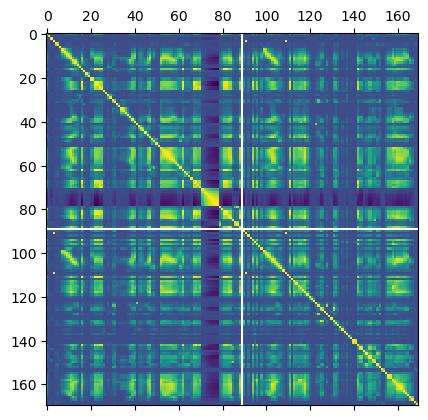

In [7]:
display(df_imputed.corr())
plt.matshow(df_imputed.corr())
plt.show()

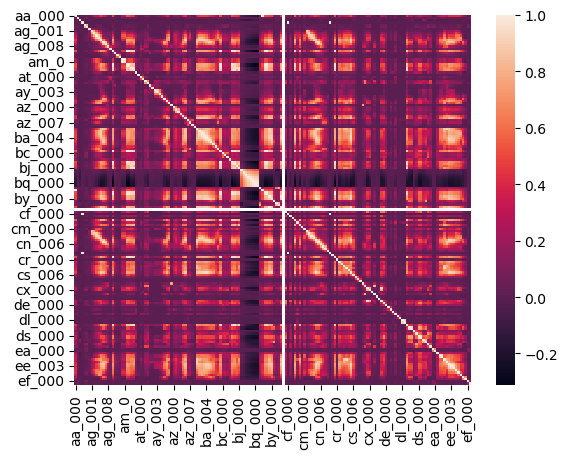

In [8]:
ax = sns.heatmap(df_imputed.corr())

#### (iv) Make scatter plots and box plots

In [9]:
d = {}
x = math.floor(math.sqrt(170))
l_sig = (coeff.sort_values(ascending=False).head(x))
l_sig_features = l_sig.index.tolist()
lsig_values = l_sig.values.tolist()
l_sig_features, lsig_values
d = dict(zip(l_sig_features, lsig_values))
df2 = pd.DataFrame(list(d.items()), columns=['Feature', 'CV'])
display(df2)

,Feature,CV
0,cf_000,207.335930
1,co_000,206.941549
2,ad_000,206.786809
3,cs_009,192.498194
4,dj_000,122.169994
5,as_000,113.895899
6,dh_000,112.666588
7,df_000,111.279258
8,ag_000,91.465520
9,au_000,86.090347


In [10]:
df3 = df_imputed[l_sig_features]

In [11]:
df3

,cf_000,co_000,ad_000,cs_009,dj_000,as_000,dh_000,df_000,ag_000,au_000,ak_000,az_009,ay_009
0,2.000000,220.000000,280.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,190221.810984,190515.566938,190620.639314,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.000000,2.000000,66.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,202.000000,458.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2.000000,42.000000,892.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15996,2.000000,0.000000,46.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15997,2.000000,378.000000,1518.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15998,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


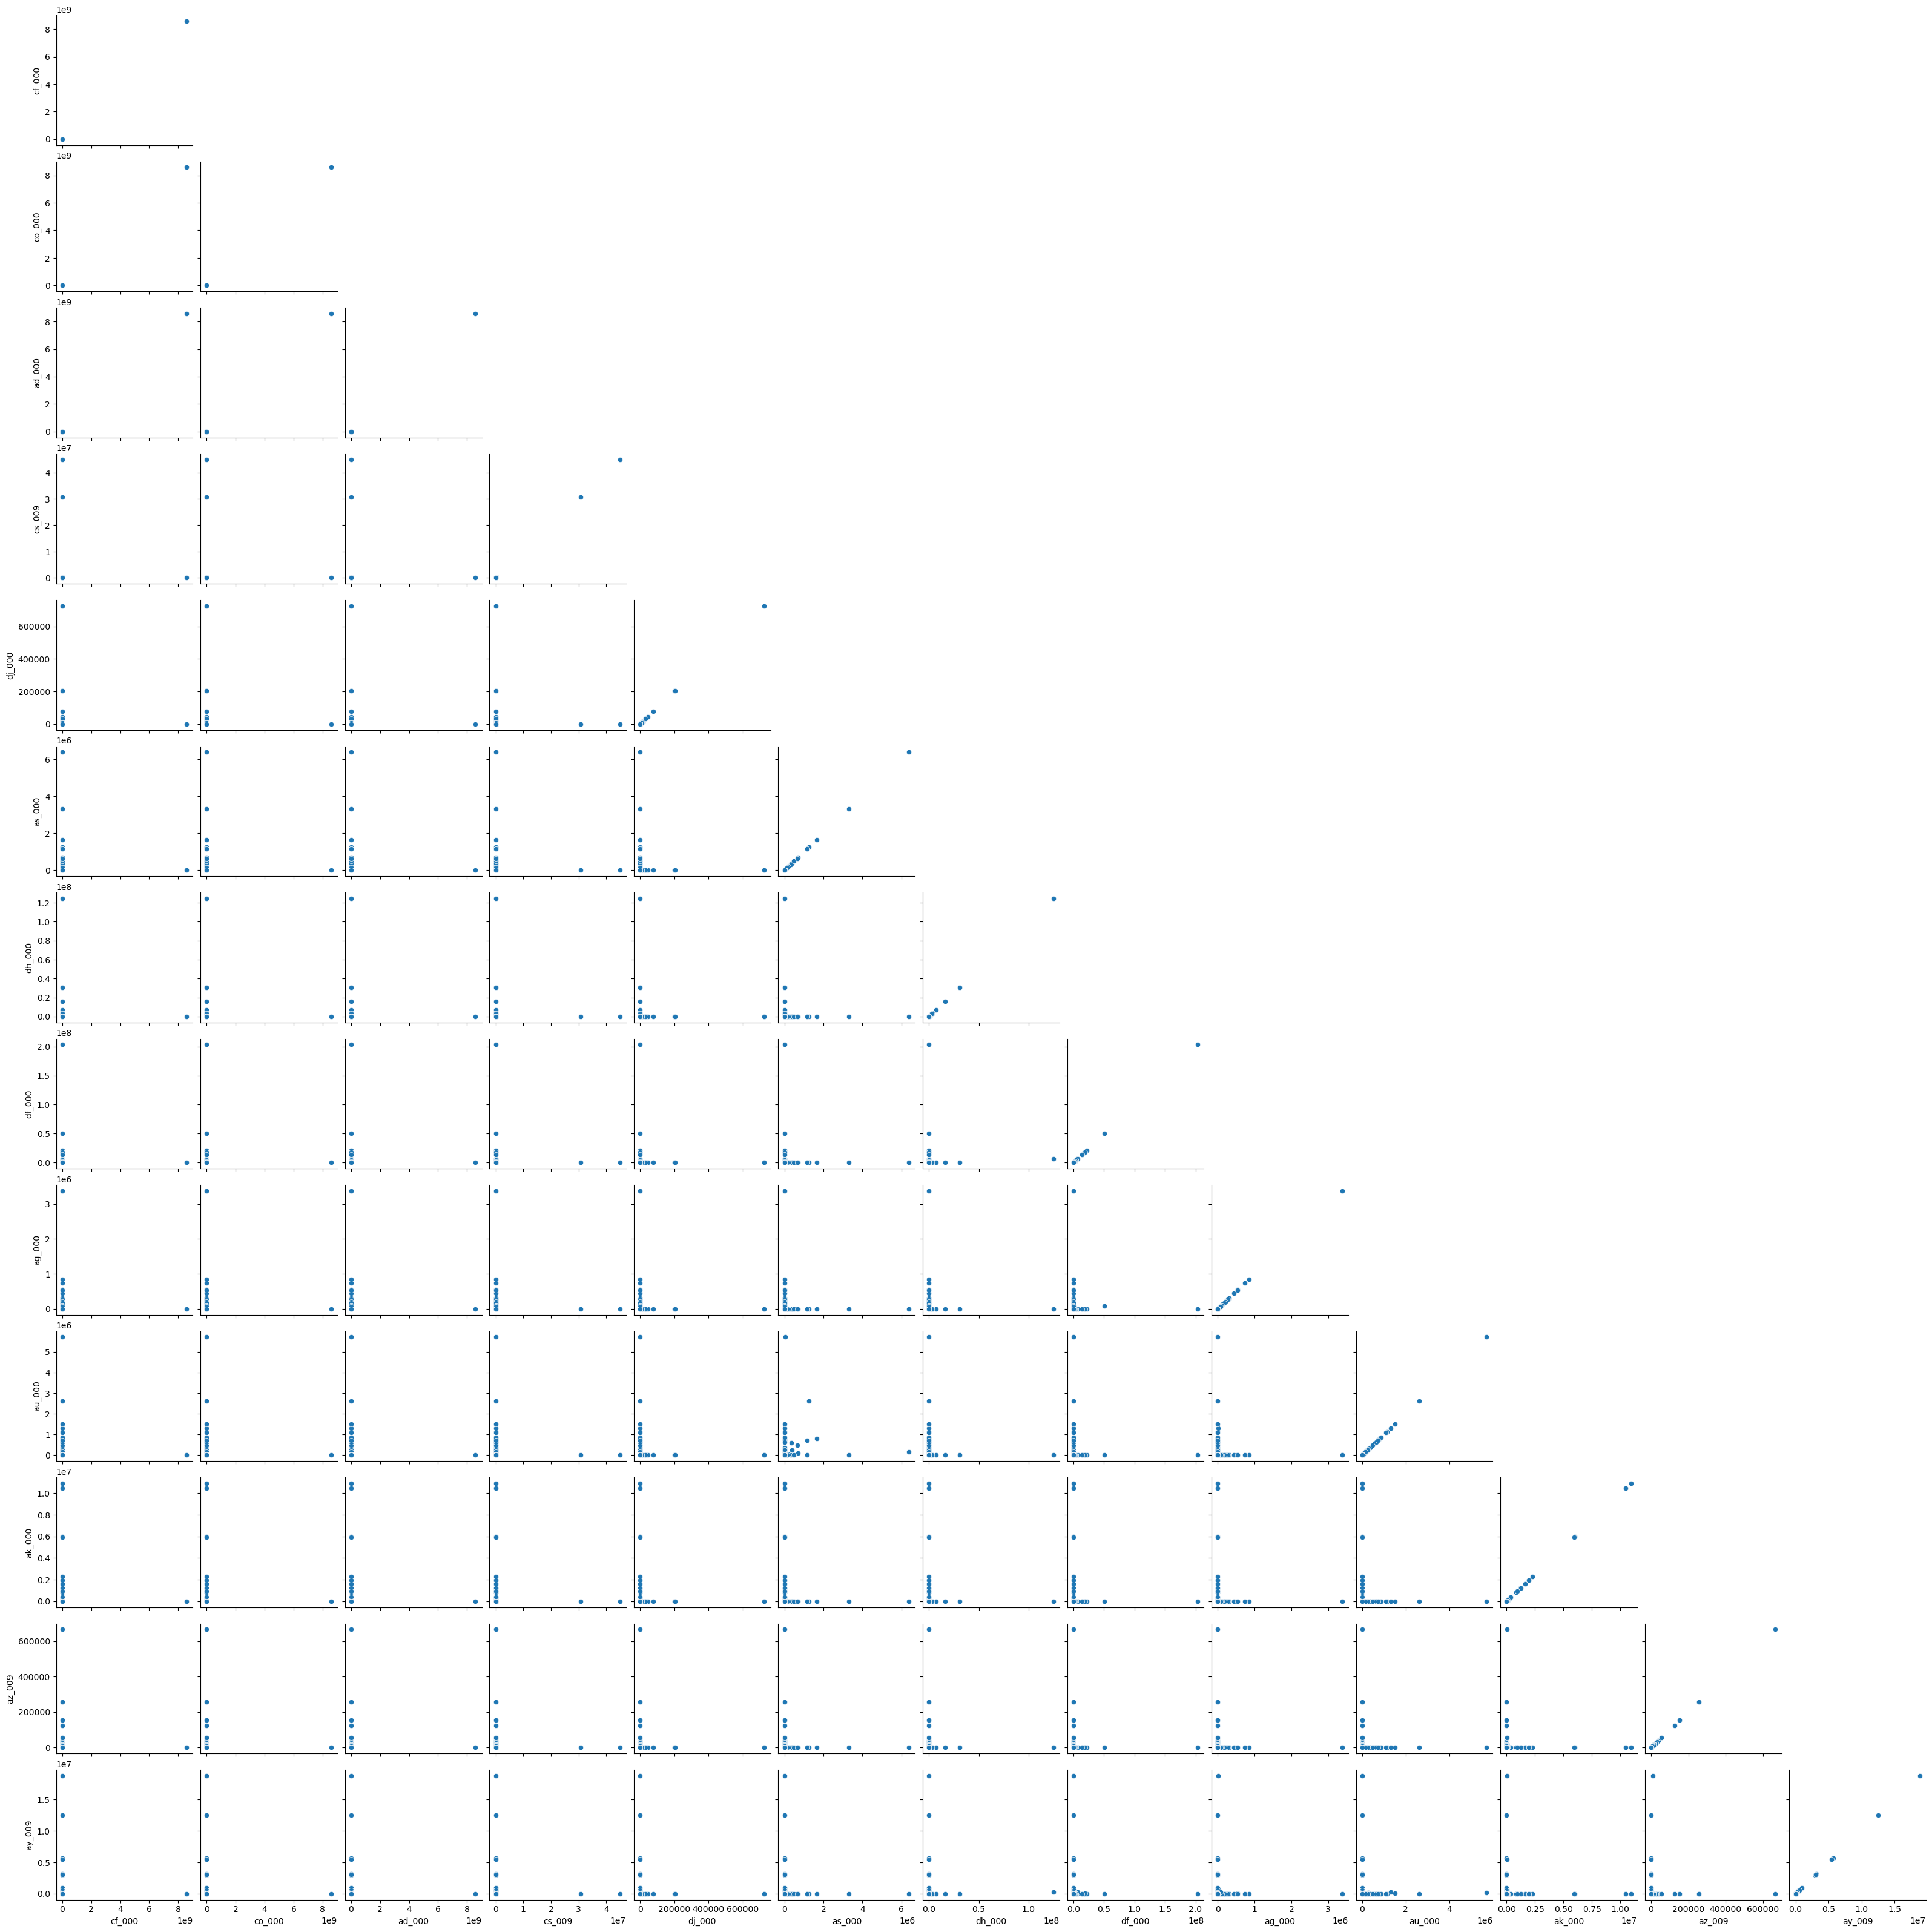

In [12]:
sns.pairplot(df3, corner=True, diag_kind=None)
plt.show()

In [13]:
df3.describe().T[['min','25%','50%','75%','max']]

,min,25%,50%,75%,max
cf_000,0.0,0.0,2.0,40.779932,8.584298e+09
co_000,0.0,2.0,32.0,776.000000,8.584298e+09
ad_000,0.0,42.0,290.0,1228.000000,8.584298e+09
cs_009,0.0,0.0,0.0,0.000000,4.490299e+07
dj_000,0.0,0.0,0.0,0.000000,7.267500e+05
as_000,0.0,0.0,0.0,0.000000,6.383704e+06
dh_000,0.0,0.0,0.0,0.000000,1.247009e+08
df_000,0.0,0.0,0.0,0.000000,2.035008e+08
ag_000,0.0,0.0,0.0,0.000000,3.376892e+06
au_000,0.0,0.0,0.0,0.000000,5.711474e+06


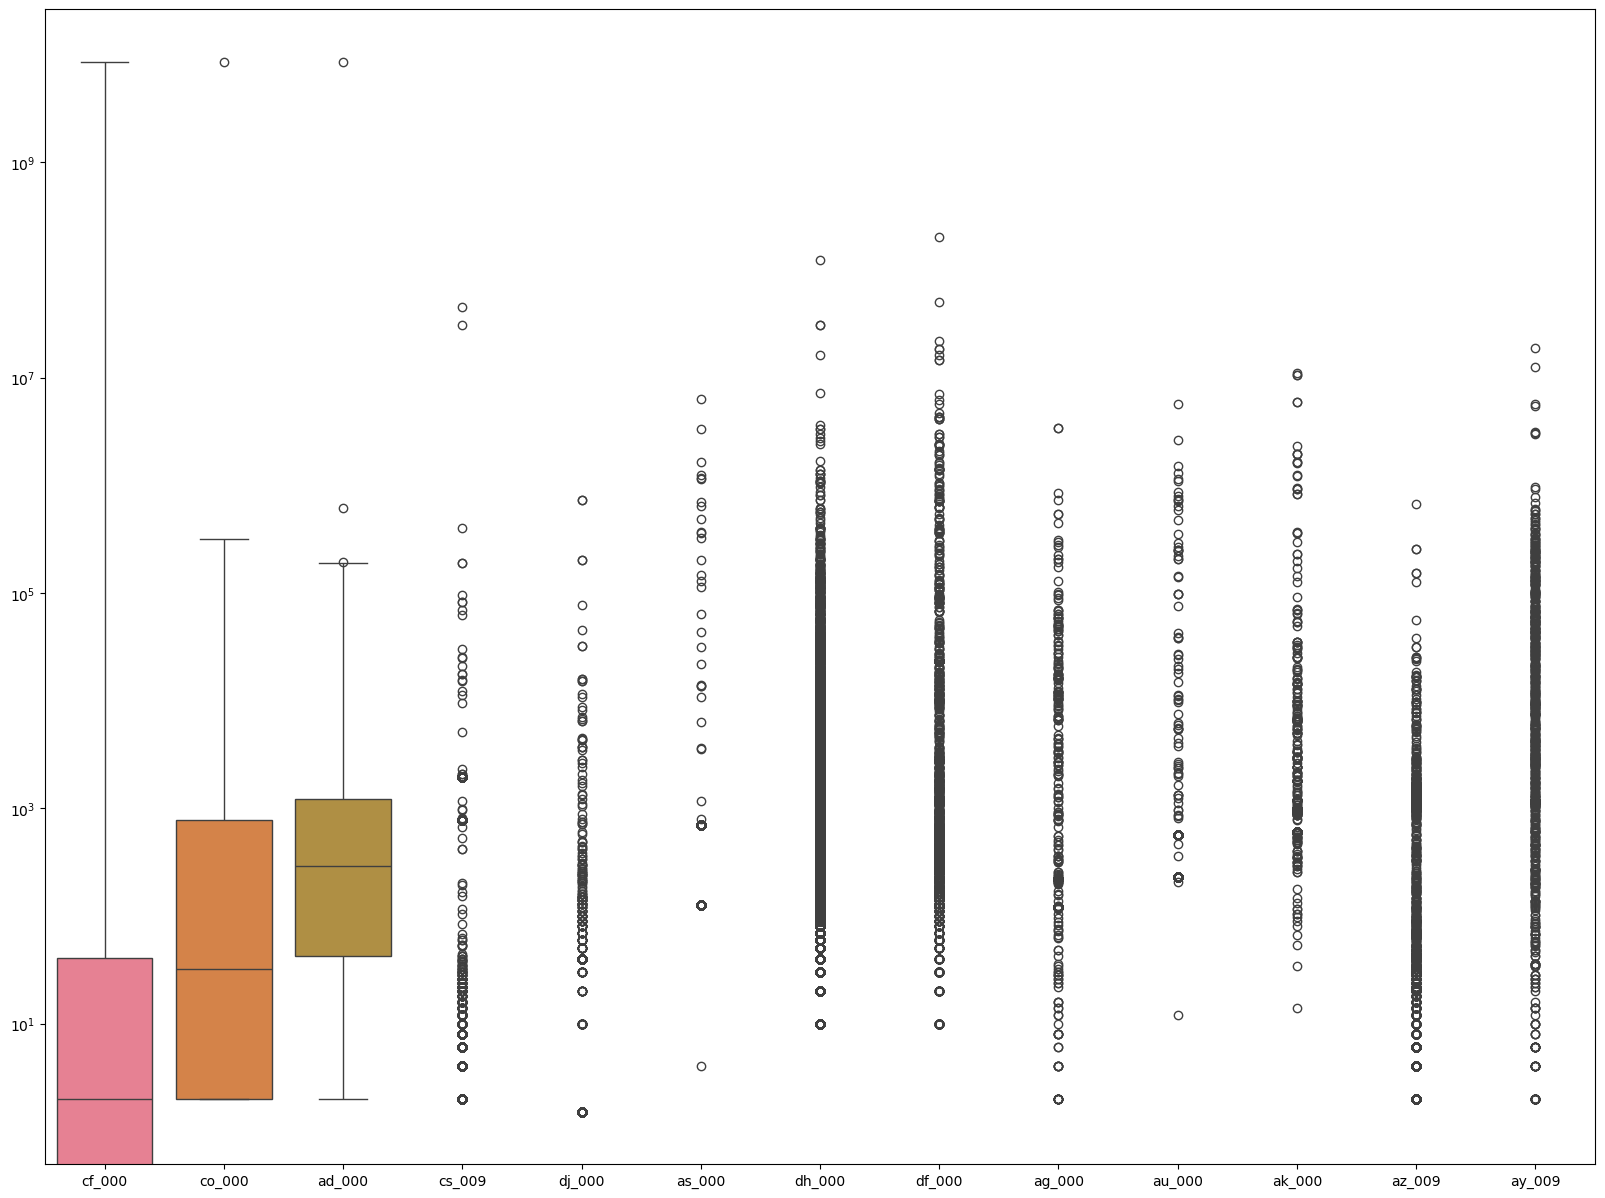

In [14]:
plt.figure(figsize=(20,15))
plt.yscale('log')
sns.boxplot(data=df3)
plt.show()

From the above plots we can observe that many of the feature values are 0, and hence IQR becomes 0 causing the boxplot above. Also from the pairplot, we observe that the data is sparse, containing more zeroes.

#### (v) Is this data set imbalanced?

In [15]:
df_train_y.value_counts()

class
neg    59000
pos     1000
Name: count, dtype: int64

In [16]:
df_test_y.value_counts()

class
neg    15625
pos      375
Name: count, dtype: int64

This dataset is highly imbalanced. The negative class data points are 54 times more frequent than the positive class data points.

### (c) Train a random forest

In [17]:
df_train_y = df_train_y.map({'neg': 0, 'pos': 1}).astype(int)
df_test_y  = df_test_y.map({'neg': 0, 'pos': 1}).astype(int)

In [18]:
clf = RandomForestClassifier(n_estimators=100, random_state=42,oob_score=True)
clf.fit(df_train_imputed, df_train_y)

RandomForestClassifier(oob_score=True, random_state=42)

In [19]:
y_train_pred = clf.predict(df_train_imputed)
print(classification_report(df_train_y, y_train_pred))
print(confusion_matrix(df_train_y, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000

[[59000     0]
 [    1   999]]


In [20]:
y_test_pred = clf.predict(df_test_imputed)
print(classification_report(df_test_y, y_test_pred))
print(confusion_matrix(df_test_y, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15625
           1       0.93      0.73      0.82       375

    accuracy                           0.99     16000
   macro avg       0.96      0.86      0.91     16000
weighted avg       0.99      0.99      0.99     16000

[[15605    20]
 [  101   274]]


In [21]:
y_test_prob  = clf.predict_proba(df_test_imputed)[:, 1]
y_train_prob = clf.predict_proba(df_train_imputed)[:, 1]

auc_test  = roc_auc_score(df_test_y,  y_test_prob)
auc_train = roc_auc_score(df_train_y, y_train_prob)

In [22]:
print(f"OOB error  : {1 - clf.oob_score_}")
print(f"Test error : {(y_test_pred != df_test_y).mean()}")

OOB error  : 0.006000000000000005
Test error : 0.0075625


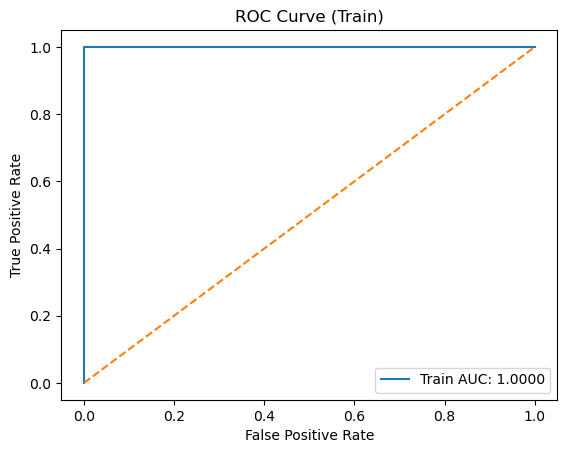

In [23]:
fpr, tpr, _ = roc_curve(df_train_y, y_train_prob)
plt.plot(fpr, tpr, label=f"Train AUC: {auc_train:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train)")
plt.legend()
plt.show()

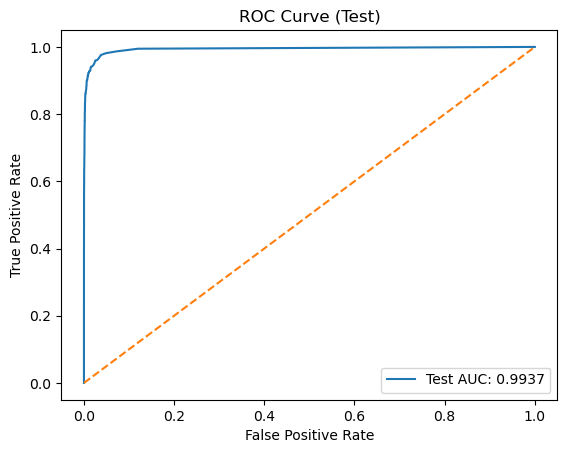

In [24]:
fpr, tpr, _ = roc_curve(df_test_y, y_test_prob)
plt.plot(fpr, tpr, label=f"Test AUC: {auc_test:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

### (d) Research class imbalance in random forest

Random forest is an ideal algorithm to deal with the extreme imbalance owing to two main reasons. Firstly, the ability to incorporate class weights into the random forest classifier makes it cost-sensitive; hence it penalizes misclassifying the minority class. Secondly, it combines the sampling technique and ensemble learning, therefore, downsampling the majority class and growing trees on a more balanced dataset. 

We can use 2 methods :-

1) Standard RF with Bagging - Each decision tree in the forest is created from randomly selected bootstrap samples, which are aggregated to make a prediction called ‘Bagging.’ Apply stratified K-fold cross validation

2) Balanced RF - Make class priors equal, either by downsampling or oversampling by iteratively drawing a bootstrap sample with equal proportions of data points from both the minority and the majority class

In [25]:
clf1 = RandomForestClassifier(n_estimators=100, random_state=42,oob_score=True, class_weight='balanced')
clf1.fit(df_train_imputed, df_train_y)

RandomForestClassifier(class_weight='balanced', oob_score=True, random_state=42)

In [26]:
y_train_pred = clf1.predict(df_train_imputed)
print(classification_report(df_train_y, y_train_pred))
print(confusion_matrix(df_train_y, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000

[[59000     0]
 [    1   999]]


In [27]:
y_test_pred = clf1.predict(df_test_imputed)
print(classification_report(df_test_y, y_test_pred))
print(confusion_matrix(df_test_y, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     15625
           1       0.94      0.54      0.69       375

    accuracy                           0.99     16000
   macro avg       0.96      0.77      0.84     16000
weighted avg       0.99      0.99      0.99     16000

[[15612    13]
 [  171   204]]


In [28]:
y_test_prob  = clf1.predict_proba(df_test_imputed)[:, 1]
y_train_prob = clf1.predict_proba(df_train_imputed)[:, 1]

auc_test  = roc_auc_score(df_test_y,  y_test_prob)
auc_train = roc_auc_score(df_train_y, y_train_prob)

In [29]:
print(f"OOB error  : {1 - clf1.oob_score_}")
print(f"Test error : {(y_test_pred != df_test_y).mean()}")

OOB error  : 0.007683333333333375
Test error : 0.0115


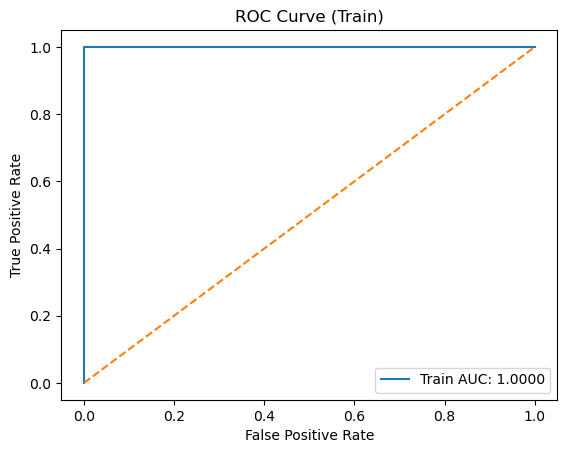

In [30]:
fpr, tpr, _ = roc_curve(df_train_y, y_train_prob)
plt.plot(fpr, tpr, label=f"Train AUC: {auc_train:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train)")
plt.legend()
plt.show()

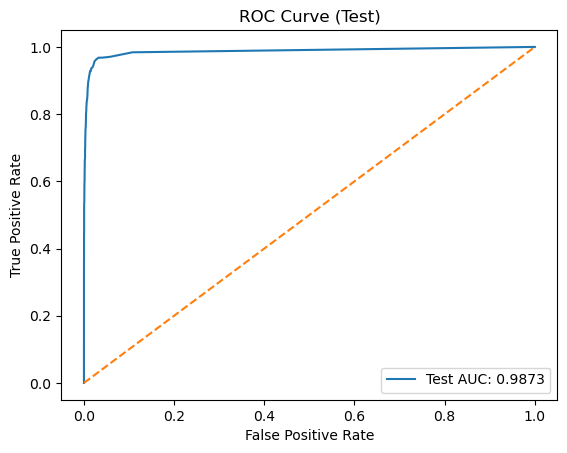

In [31]:
fpr, tpr, _ = roc_curve(df_test_y, y_test_prob)
plt.plot(fpr, tpr, label=f"Test AUC: {auc_test:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

-----------------

In [32]:
clf2 = BalancedRandomForestClassifier(n_estimators=100, random_state=42,oob_score=True)
clf2.fit(df_train_imputed, df_train_y)

BalancedRandomForestClassifier(oob_score=True, random_state=42)

In [33]:
y_train_pred = clf2.predict(df_train_imputed)
print(classification_report(df_train_y, y_train_pred))
print(confusion_matrix(df_train_y, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     59000
           1       0.24      1.00      0.39      1000

    accuracy                           0.95     60000
   macro avg       0.62      0.97      0.68     60000
weighted avg       0.99      0.95      0.96     60000

[[55868  3132]
 [    0  1000]]


In [34]:
y_test_pred = clf2.predict(df_test_imputed)
print(classification_report(df_test_y, y_test_pred))
print(confusion_matrix(df_test_y, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     15625
           1       0.31      0.98      0.47       375

    accuracy                           0.95     16000
   macro avg       0.66      0.96      0.72     16000
weighted avg       0.98      0.95      0.96     16000

[[14812   813]
 [    7   368]]


In [35]:
y_test_prob  = clf2.predict_proba(df_test_imputed)[:, 1]
y_train_prob = clf2.predict_proba(df_train_imputed)[:, 1]

auc_test  = roc_auc_score(df_test_y,  y_test_prob)
auc_train = roc_auc_score(df_train_y, y_train_prob)

In [36]:
print(f"OOB error  : {1 - clf2.oob_score_}")
print(f"Test error : {(y_test_pred != df_test_y).mean()}")

OOB error  : 0.03313333333333335
Test error : 0.05125


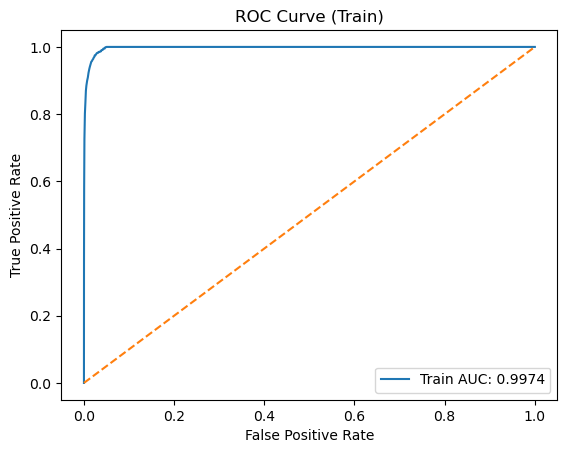

In [37]:
fpr, tpr, _ = roc_curve(df_train_y, y_train_prob)
plt.plot(fpr, tpr, label=f"Train AUC: {auc_train:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train)")
plt.legend()
plt.show()

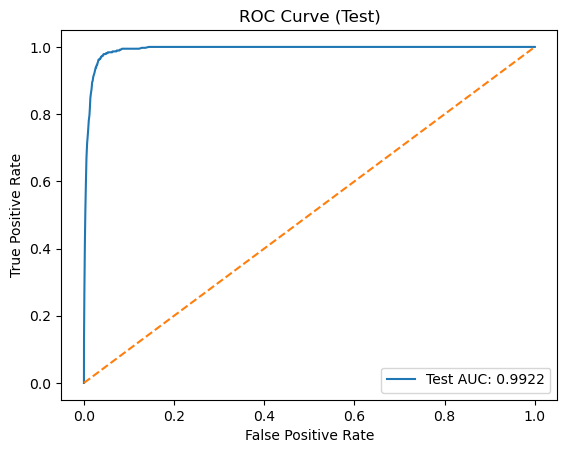

In [38]:
fpr, tpr, _ = roc_curve(df_test_y, y_test_prob)
plt.plot(fpr, tpr, label=f"Test AUC: {auc_test:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

We see that the RF with bagging is best to classify true positive and true negative classes. We also see a reduction in misclassifications of the positive class after handling class imbalance

### (e) XGBoost and Model Trees

In [39]:
results = []

In [40]:
bst = XGBClassifier(n_estimators=100, eval_metric = 'logloss', objective='binary:logistic', random_state=42)
param_grid = {
    'reg_alpha': [0, 0.0001, 0.01, 0.1, 1, 10, 100, 1000],
}
grid_5 = GridSearchCV(estimator=bst, param_grid=param_grid, scoring='roc_auc', cv=5)
grid_5.fit(df_train_imputed, df_train_y)
print("Best alpha:", grid_5.best_params_)


Best alpha: {'reg_alpha': 0.01}


In [41]:
bst = XGBClassifier(n_estimators=100, eval_metric = 'logloss', objective='binary:logistic', random_state=42, reg_alpha=grid_5.best_params_['reg_alpha'])
bst.fit(df_train_imputed, df_train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [42]:
y_train_pred = bst.predict(df_train_imputed)
print(classification_report(df_train_y, y_train_pred))
print(confusion_matrix(df_train_y, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000

[[59000     0]
 [    1   999]]


In [43]:
y_test_pred = bst.predict(df_test_imputed)
print(classification_report(df_test_y, y_test_pred))
print(confusion_matrix(df_test_y, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15625
           1       0.92      0.75      0.83       375

    accuracy                           0.99     16000
   macro avg       0.96      0.88      0.91     16000
weighted avg       0.99      0.99      0.99     16000

[[15602    23]
 [   92   283]]


In [44]:
y_test_prob  = bst.predict_proba(df_test_imputed)[:, 1]
y_train_prob = bst.predict_proba(df_train_imputed)[:, 1]

auc_test  = roc_auc_score(df_test_y,  y_test_prob)
auc_train = roc_auc_score(df_train_y, y_train_prob)

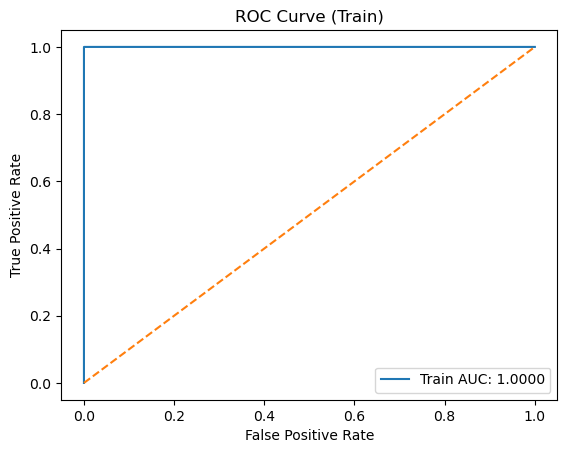

In [45]:
fpr, tpr, _ = roc_curve(df_train_y, y_train_prob)
plt.plot(fpr, tpr, label=f"Train AUC: {auc_train:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train)")
plt.legend()
plt.show()

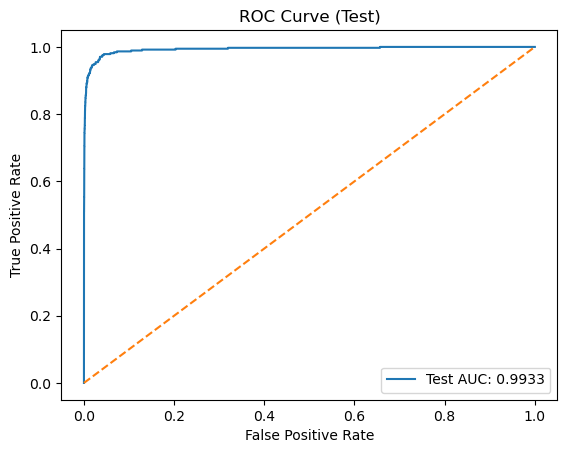

In [46]:
fpr, tpr, _ = roc_curve(df_test_y, y_test_prob)
plt.plot(fpr, tpr, label=f"Test AUC: {auc_test:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

In [47]:
train_error = 1 - (y_train_pred == df_train_y).mean()
test_error  = 1 - (y_test_pred == df_test_y).mean()

print("Train error:", train_error)
print("Test error:", test_error)

Train error: 1.666666666666483e-05
Test error: 0.007187500000000013


In [48]:
train_acc = accuracy_score(df_train_y, y_train_pred)
test_acc  = accuracy_score(df_test_y, y_test_pred)

train_auc = roc_auc_score(df_train_y, y_train_prob)
test_auc  = roc_auc_score(df_test_y, y_test_prob)

In [49]:
results.append({
    "Model": "XGB",
    "CV": "5-fold",
    "SMOTE": "No",
    "Train Acc": train_acc,
    "Test Acc": test_acc,
    "Train Error": train_error,
    "Test Error": test_error,
    "Train AUC": train_auc,
    "Test AUC": test_auc
})

-----------------

10 fold cross validation

In [50]:
bst = XGBClassifier(n_estimators=100, eval_metric = 'logloss', objective='binary:logistic', random_state=42)
param_grid = {
    'reg_alpha': [0, 0.0001, 0.01, 0.1, 1, 10, 100, 1000],
}
grid_10 = GridSearchCV(estimator=bst, param_grid=param_grid, scoring='roc_auc', cv=10)
grid_10.fit(df_train_imputed, df_train_y)
print("Best alpha:", grid_10.best_params_)


Best alpha: {'reg_alpha': 0}


In [51]:
bst = XGBClassifier(n_estimators=100, eval_metric = 'logloss', objective='binary:logistic', random_state=42, reg_alpha=grid_10.best_params_['reg_alpha'])
bst.fit(df_train_imputed, df_train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [52]:
y_train_pred = bst.predict(df_train_imputed)
print(classification_report(df_train_y, y_train_pred))
print(confusion_matrix(df_train_y, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000

[[59000     0]
 [    1   999]]


In [53]:
y_test_pred = bst.predict(df_test_imputed)
print(classification_report(df_test_y, y_test_pred))
print(confusion_matrix(df_test_y, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15625
           1       0.92      0.77      0.84       375

    accuracy                           0.99     16000
   macro avg       0.96      0.88      0.92     16000
weighted avg       0.99      0.99      0.99     16000

[[15601    24]
 [   86   289]]


In [54]:
y_test_prob  = bst.predict_proba(df_test_imputed)[:, 1]
y_train_prob = bst.predict_proba(df_train_imputed)[:, 1]

auc_test  = roc_auc_score(df_test_y,  y_test_prob)
auc_train = roc_auc_score(df_train_y, y_train_prob)

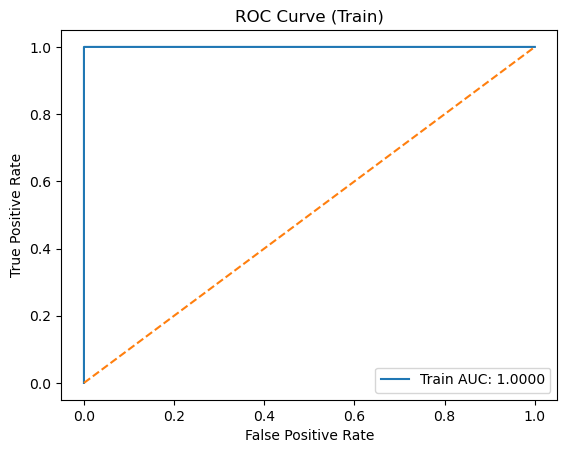

In [55]:
fpr, tpr, _ = roc_curve(df_train_y, y_train_prob)
plt.plot(fpr, tpr, label=f"Train AUC: {auc_train:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train)")
plt.legend()
plt.show()

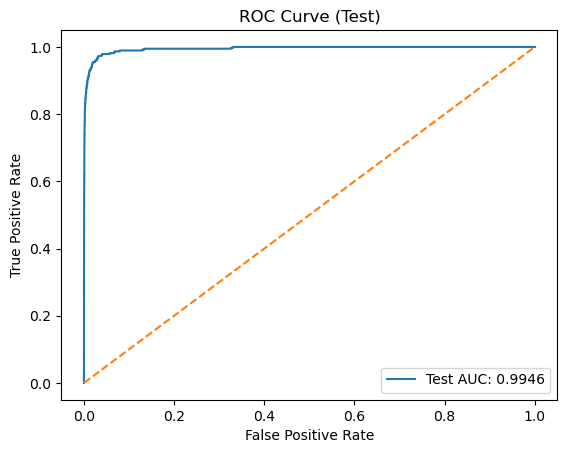

In [56]:
fpr, tpr, _ = roc_curve(df_test_y, y_test_prob)
plt.plot(fpr, tpr, label=f"Test AUC: {auc_test:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

In [57]:
train_error = 1 - (y_train_pred == df_train_y).mean()
test_error  = 1 - (y_test_pred == df_test_y).mean()

print("Train error:", train_error)
print("Test error:", test_error)

Train error: 1.666666666666483e-05
Test error: 0.0068749999999999645


In [58]:
train_acc = accuracy_score(df_train_y, y_train_pred)
test_acc  = accuracy_score(df_test_y, y_test_pred)

train_auc = roc_auc_score(df_train_y, y_train_prob)
test_auc  = roc_auc_score(df_test_y, y_test_prob)

In [59]:
results.append({
    "Model": "XGB",
    "CV": "10-fold",
    "SMOTE": "No",
    "Train Acc": train_acc,
    "Test Acc": test_acc,
    "Train Error": train_error,
    "Test Error": test_error,
    "Train AUC": train_auc,
    "Test AUC": test_auc
})

In [60]:
print(results)

[{'Model': 'XGB', 'CV': '5-fold', 'SMOTE': 'No', 'Train Acc': 0.9999833333333333, 'Test Acc': 0.9928125, 'Train Error': 1.666666666666483e-05, 'Test Error': 0.007187500000000013, 'Train AUC': 0.999999966101695, 'Test AUC': 0.9933460479999999}, {'Model': 'XGB', 'CV': '10-fold', 'SMOTE': 'No', 'Train Acc': 0.9999833333333333, 'Test Acc': 0.993125, 'Train Error': 1.666666666666483e-05, 'Test Error': 0.0068749999999999645, 'Train AUC': 1.0, 'Test AUC': 0.9946180266666667}]


### (f) Use SMOTE to pre-process your data

In [61]:
print("Before SMOTE:")
print(df_train_y.value_counts())
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(df_train_imputed, df_train_y)
print("After SMOTE:")
print(pd.Series(y_resampled).value_counts())

Before SMOTE:
class
0    59000
1     1000
Name: count, dtype: int64
After SMOTE:
class
0    59000
1    59000
Name: count, dtype: int64


In [62]:
smote = SMOTE(random_state=42)
pipeline = Pipeline([('smote', smote), ('xgb', XGBClassifier(n_estimators=100, eval_metric='logloss', objective='binary:logistic', random_state=42))])
param_grid = {
    'xgb__reg_alpha': [0, 0.0001, 0.01, 0.1, 1, 10, 100, 1000],
}
grid_5_smote = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='roc_auc', cv=5)
grid_5_smote.fit(df_train_imputed, df_train_y)
print("Best alpha:", grid_5_smote.best_params_)

Best alpha: {'xgb__reg_alpha': 0.1}


In [63]:
smote_model = grid_5_smote.best_estimator_

In [64]:
y_train_pred = smote_model.predict(df_train_imputed)
print(classification_report(df_train_y, y_train_pred))
print(confusion_matrix(df_train_y, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000

[[59000     0]
 [    1   999]]


In [65]:
y_test_pred = smote_model.predict(df_test_imputed)
print(classification_report(df_test_y, y_test_pred))
print(confusion_matrix(df_test_y, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     15625
           1       0.59      0.87      0.70       375

    accuracy                           0.98     16000
   macro avg       0.79      0.93      0.85     16000
weighted avg       0.99      0.98      0.98     16000

[[15395   230]
 [   49   326]]


In [66]:
y_test_prob  = smote_model.predict_proba(df_test_imputed)[:, 1]
y_train_prob = smote_model.predict_proba(df_train_imputed)[:, 1]

auc_test  = roc_auc_score(df_test_y,  y_test_prob)
auc_train = roc_auc_score(df_train_y, y_train_prob)

In [67]:
train_error = 1 - (y_train_pred == df_train_y).mean()
test_error  = 1 - (y_test_pred == df_test_y).mean()

print("Train error:", train_error)
print("Test error:", test_error)

Train error: 1.666666666666483e-05
Test error: 0.017437499999999995


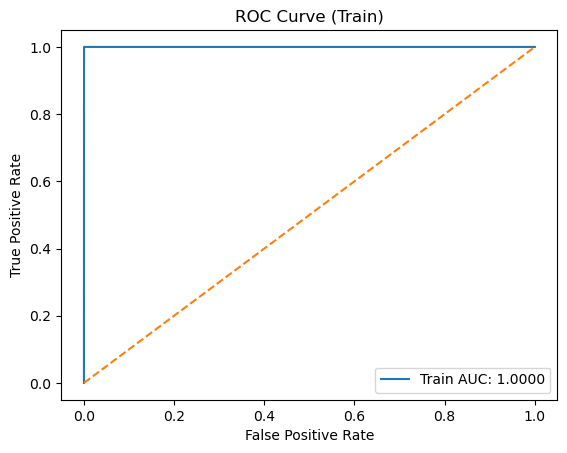

In [68]:
fpr, tpr, _ = roc_curve(df_train_y, y_train_prob)
plt.plot(fpr, tpr, label=f"Train AUC: {auc_train:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train)")
plt.legend()
plt.show()

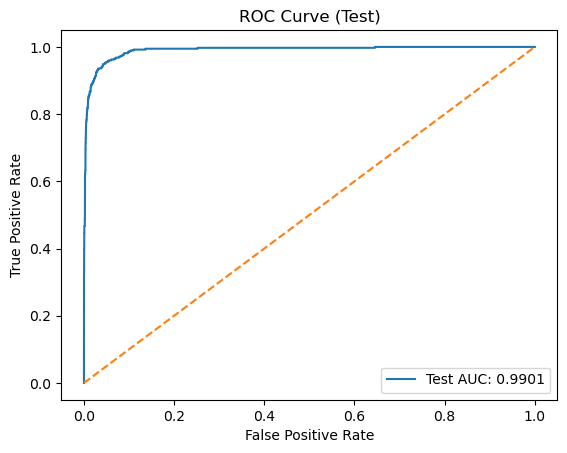

In [69]:
fpr, tpr, _ = roc_curve(df_test_y, y_test_prob)
plt.plot(fpr, tpr, label=f"Test AUC: {auc_test:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

In [70]:
train_acc = accuracy_score(df_train_y, y_train_pred)
test_acc  = accuracy_score(df_test_y, y_test_pred)

train_auc = roc_auc_score(df_train_y, y_train_prob)
test_auc  = roc_auc_score(df_test_y, y_test_prob)

In [71]:
results.append({
    "Model": "XGB",
    "CV": "No",
    "SMOTE": "Yes",
    "Train Acc": train_acc,
    "Test Acc": test_acc,
    "Train Error": train_error,
    "Test Error": test_error,
    "Train AUC": train_auc,
    "Test AUC": test_auc
})

In [72]:
results_df = pd.DataFrame(results)
display(results_df)

,Model,CV,SMOTE,Train Acc,Test Acc,Train Error,Test Error,Train AUC,Test AUC
0,XGB,5-fold,No,0.999983,0.992812,0.000017,0.007188,1.0,0.993346
1,XGB,10-fold,No,0.999983,0.993125,0.000017,0.006875,1.0,0.994618
2,XGB,No,Yes,0.999983,0.982563,0.000017,0.017437,1.0,0.990122


In [73]:
# df_train_smote_X, df_train_smote_y = smote.fit_resample(df_train_imputed, df_train_y)
# print(df_train_y.value_counts())
# print(df_train_smote_y.value_counts())

## 2. ISLR 6.6.3

This is the LASSO regression constraint formula to minimize RSS. s determines the amount of regularization.

a) iv. Steadily decrease - as s increases, model becomes more flexible, all β's increase from 0 to least square estimate values. 

b) ii. Decrease initially, then start increasing in U shape - when s-0 model has high test RSS, which decreases as we start increasing s since the model fits data well. As the sincreases past the overfitting range the test RSS increases again.

c) iii. Steadily increase - when β=0 variance also almost equals 0. A larger s reduces regularization penalty making the model sensitive to training data and almost overfitting, thus increasing variance

d) iv. Steadily decrease - as bias-variance tradeoff makes bias decrease when variance increases, and as s increases model fits data better reducing bias

e) v. Reamain constant - irreducible error is model independent and any change in s doesn't impact it.


## 3. ISLR 6.6.5

a) Ridge regression is sum of squared errors + L2 penalty and we minimize the formula 

$$
\min_{} \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2 + \lambda \sum_{j=1}^{p} \beta_j^2
$$

we have n=2, p=2 so substituting all values 

$$
\min_{} \left(y_1 - \beta_1 x_{11} - \beta_2 x_{12} \right)^2 + \left(y_2 - \beta_1 x_{21} - \beta_2 x_{22} \right)^2 + \lambda \left(\beta_1^2 + \beta_2^2\right)^2
$$

-----------------

b) When $x11=x12=x1$ and $x21=x22=x2$
take derivatives of the new expression 
$$
\min_{} \left(y_1 - \beta_1 x_{1} - \beta_2 x_{1} \right)^2 + \left(y_2 - \beta_1 x_{2} - \beta_2 x_{2} \right)^2 + \lambda \left(\beta_1^2 + \beta_2^2\right)^2
$$

wrt $\beta_1$  and  $\beta_2 $

$$
\frac{\partial}{\partial{\beta_1}} = 
  - 2y_1x_1 + 2\beta_1x_1^2 + 2\beta_2x_1^2
  - 2y_2x_2 + 2\beta_1x_2^2 + 2\beta_2x_2^2
  + 2\lambda\beta_1
$$

$$
\frac{\partial}{\partial{\beta_2}} = 
  - 2y_1x_1 + 2\beta_1x_1^2 + 2\beta_2x_1^2
  - 2y_2x_2 + 2\beta_1x_2^2 + 2\beta_2x_2^2
  + 2\lambda\beta_2
$$
Equate to 0
$$
\frac{\partial}{\partial{\beta_1}} =  \frac{\partial}{\partial{\beta_2}} = 0
$$

We can see that $\lambda\beta_1$ = $\lambda\beta_2$, Thus $\beta_1$ = $\beta_2$

----------------

c) Lasso 
we minimize the formula 

$$
\min_{} \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$


$$
\min_{} \left(y_1 - \beta_1 x_{11} - \beta_2 x_{12} \right)^2 + \left(y_2 - \beta_1 x_{21} - \beta_2 x_{22} \right)^2 + \lambda \left(|\beta_1| + |\beta_2|\right)
$$


-------------------

d) Taking derivative of the above wrt $\beta_1$  and  $\beta_2 $


$$
\frac{\partial}{\partial{\beta_1}} = 
  - 2y_1x_1 + 2\beta_1x_1^2 + 2\beta_2x_1^2
  - 2y_2x_2 + 2\beta_1x_2^2 + 2\beta_2x_2^2
  + 2\lambda \frac{|\beta_1|}{\beta_1}
$$

$$
\frac{\partial}{\partial{\beta_2}} = 
  - 2y_1x_1 + 2\beta_1x_1^2 + 2\beta_2x_1^2
  - 2y_2x_2 + 2\beta_1x_2^2 + 2\beta_2x_2^2
  + 2\lambda \frac{|\beta_2|}{\beta_2}
$$
Equate to 0
$$
\frac{\partial}{\partial{\beta_1}} =  \frac{\partial}{\partial{\beta_2}} = 0
$$

We get 

$$
\frac{|\beta_1|}{\beta_1} = \frac{|\beta_2|}{\beta_2}

$$

which can have multiple solutions as $\beta_1$ and $\beta_2$ could be + or -

## 4. ISLR 8.4.5

i) Majority voting - The number of Red predictions is the sum(P>0.5) = 6. The number of green predictions is 4. Thus by majority voting we calssify it as Red.

II) Average probability - mean is 0.45, which is <0.5 so the classification is green.

## 5. ISLR 9.7.3

a) Sketching the observations

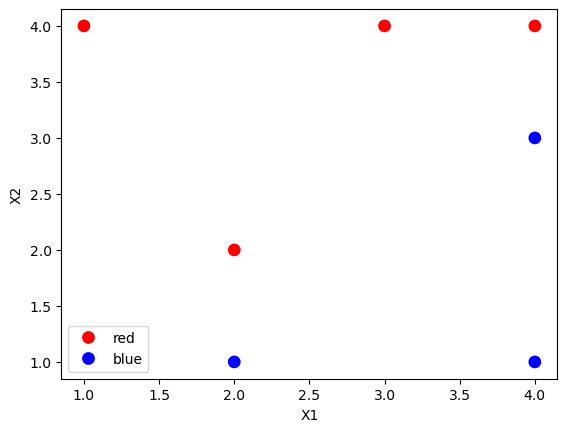

In [74]:
data = pd.DataFrame({'X1': [3, 2, 4, 1, 2, 4, 4], 'X2':[4, 2, 4, 4, 1, 3, 1], 'Y':['red', 'red', 'red', 'red', 'blue', 'blue', 'blue']})
sns.scatterplot(x=data['X1'], y=data['X2'], hue=data['Y'], s=100, palette={'red': 'red', 'blue': 'blue'})

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

b) Hyperplane

In [75]:
X = data[['X1', 'X2']].values
y = data['Y'].values
# y = np.where(y == 'red', 1, -1)
model = SVC(kernel='linear', C=100)
model.fit(X, y)
w = model.coef_[0]
b = model.intercept_[0]
print(f"Hyperplane Equation: {w[0]:.5f}*x + {w[1]:.5f}*y + {b:.5f} = 0")

Hyperplane Equation: -1.99941*x + 1.99941*y + 0.99971 = 0


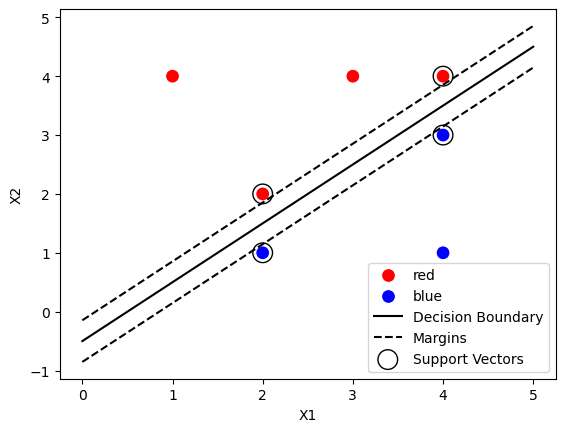

In [76]:
xx = np.linspace(0, 5, 100)
yy = -(w[0]*xx + b) / w[1]
margin = 1 / np.linalg.norm(w)
y_margin_up = yy + margin
y_margin_down = yy - margin

sns.scatterplot(x=data['X1'], y=data['X2'], hue=data['Y'],
                s=100, palette={'red': 'red', 'blue': 'blue'})

plt.plot(xx, yy, 'k-', label='Decision Boundary')

plt.plot(xx, y_margin_up, 'k--', label='Margins')
plt.plot(xx, y_margin_down, 'k--')

plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=200, facecolors='none', edgecolors='black',
            label='Support Vectors')

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()

plt.show()

c) The equation is of the form -x1 + x2 + 0.5 = 0. The standard format is β₀ + β₁X₁ + β₂X₂ = 0. So if 0.5 - x1 + x2 > 0 classify red, else blue.

d, e are plotted in graph.

f) x1, x2 = 4, 1
This point is far away from the hyperplane and not within the boundary and thus a slight change would keep it on the same side of the hyperplane, not causing change to maximal margin.

g) A sub-optimal hyperplane would be just below the (2,2) and (4,3) points or even passing through both. So line is x2-0.5x1-1 = 0, or even x2 = 0.75x1 + 0.25

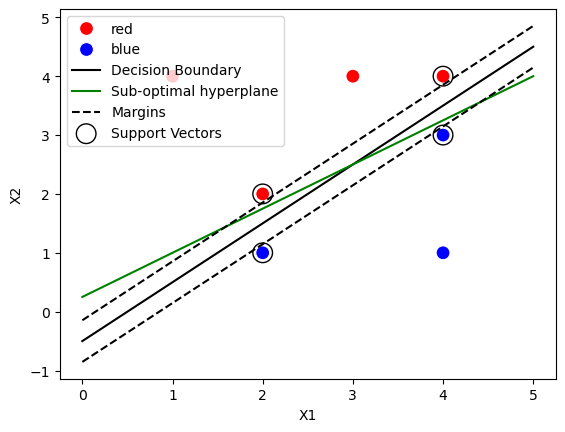

In [77]:
xx = np.linspace(0, 5, 100)
yy = -(w[0]*xx + b) / w[1]
yy2 = -(-0.75*xx -0.25) / 1
# yy2 = -(-0.5*xx -1) / 1
margin = 1 / np.linalg.norm(w)
y_margin_up = yy + margin
y_margin_down = yy - margin

sns.scatterplot(x=data['X1'], y=data['X2'], hue=data['Y'],
                s=100, palette={'red': 'red', 'blue': 'blue'})

plt.plot(xx, yy, 'k-', label='Decision Boundary')
plt.plot(xx, yy2, 'g', label='Sub-optimal hyperplane')
plt.plot(xx, y_margin_up, 'k--', label='Margins')
plt.plot(xx, y_margin_down, 'k--')

plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=200, facecolors='none', edgecolors='black',
            label='Support Vectors')

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()

plt.show()

h) Adding 1, 3, blue

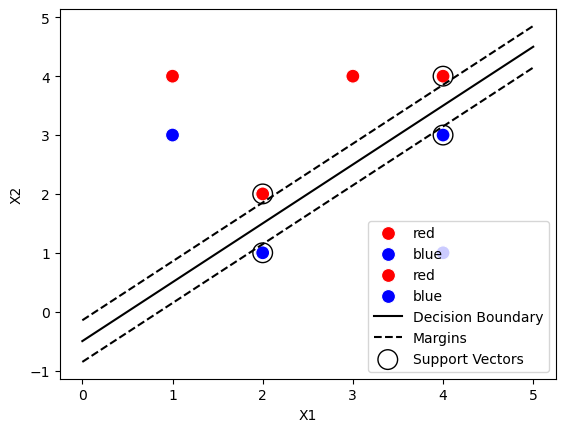

In [78]:
data = pd.DataFrame({'X1': [3, 2, 4, 1, 2, 4, 4, 1], 'X2':[4, 2, 4, 4, 1, 3, 1, 3], 'Y':['red', 'red', 'red', 'red', 'blue', 'blue', 'blue', 'blue']})
sns.scatterplot(x=data['X1'], y=data['X2'], hue=data['Y'], s=100, palette={'red': 'red', 'blue': 'blue'})

xx = np.linspace(0, 5, 100)
yy = -(w[0]*xx + b) / w[1]
margin = 1 / np.linalg.norm(w)
y_margin_up = yy + margin
y_margin_down = yy - margin

sns.scatterplot(x=data['X1'], y=data['X2'], hue=data['Y'],
                s=100, palette={'red': 'red', 'blue': 'blue'})

plt.plot(xx, yy, 'k-', label='Decision Boundary')

plt.plot(xx, y_margin_up, 'k--', label='Margins')
plt.plot(xx, y_margin_down, 'k--')

plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=200, facecolors='none', edgecolors='black',
            label='Support Vectors')

plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()

plt.show()

### References

https://stackoverflow.com/questions/58512113/how-to-count-class-label-frequency-in-a-data-frame-using-pandas

https://stackoverflow.com/questions/37612434/what-are-ways-to-speed-up-seaborns-pairplot

https://medium.com/sfu-cspmp/surviving-in-a-random-forest-with-imbalanced-datasets-b98b963d52eb

https://stackoverflow.com/questions/68766331/how-to-apply-predict-to-xgboost-cross-validation

https://stackoverflow.com/questions/50245684/using-smote-with-gridsearchcv-in-scikit-learn

https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/

https://stackoverflow.com/questions/46511017/plot-hyperplane-linear-svm-python



### AI Prompts

Code fixing and cleanup

How to increase interpretability of boxplots

Speed up pairplots

How to use do grid cross validation with smote

Explain the formula of LASSO regression

Correct way of doing cross validation with smote

How to plot a hyperplane